<a href="https://colab.research.google.com/github/Arpon7/VoltVARControl/blob/main/VoltVARControl_V2.0/VoltVARControl_V2.0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

this is the staring point of v2.0 (instead of witing down in Notion). I did all the experiments here.

In [1]:
!git clone https://github.com/JieFeng-cse/Stable-DDPG-for-voltage-control.git
%cd Stable-DDPG-for-voltage-control

Cloning into 'Stable-DDPG-for-voltage-control'...
remote: Enumerating objects: 333, done.
remote: Counting objects: 100% (333/333), done.
remote: Compressing objects: 100% (256/256), done.
remote: Total 333 (delta 90), reused 309 (delta 71), pack-reused 0 (from 0)
Receiving objects: 100% (333/333), 4.79 MiB | 17.89 MiB/s, done.
Resolving deltas: 100% (90/90), done.
/content/Stable-DDPG-for-voltage-control


In [2]:
!pip install -q pandapower numba

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 68.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 106.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.8/447.8 kB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.2/80.2 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.2/398.2 kB 31.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires 

In [3]:
import sys
import numpy
import scipy
import pandas
import pandapower
import gym

print("Python:", sys.version)
print("NumPy:", numpy.__version__)
print("SciPy:", scipy.__version__)
print("Pandas:", pandas.__version__)
print("Gym:", gym.__version__)
print("pandapower:", pandapower.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy: 2.0.2
SciPy: 1.18.0
Pandas: 2.3.3
Gym: 0.25.2
pandapower: 3.5.4


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [9]:
#Current environment code in this repository uses an older pandapower interface:
#pp_net = pp.converter.from_mpc(pp_model_pth, casename_mpc_file='case_mpc')
# For newer pandapower versions, use:
# from pandapower.converter.matpower import from_mpc
# pp_net = from_mpc(pp_model_pth, casename_mpc_file='case_mpc')
# Install numba in your environment for newer pandapower compatibility/performance:
# pip install numba
# If your local setup is already built around the older pandapower API, keep the current code path unchanged.
!sed -i "s/pp_net = pp.converter.from_mpc(/pp_net = from_mpc(/" env_single_phase_13bus.py
!sed -i "/import pandapower.networks as pn/a from pandapower.converter.matpower import from_mpc" env_single_phase_13bus.py
!sed -i "s/pp_net = pp.converter.from_mpc(/pp_net = from_mpc(/" env_single_phase_123bus.py
!sed -i "/import pandapower.networks as pn/a from pandapower.converter.matpower import from_mpc" env_single_phase_123bus.py

In [5]:
!find "pandapower models" -type f

pandapower models/__MACOSX/pandapower models/._123bus.png
pandapower models/__MACOSX/pandapower models/._case_13.mat
pandapower models/__MACOSX/pandapower models/._case123.m
pandapower models/__MACOSX/pandapower models/._.DS_Store
pandapower models/__MACOSX/pandapower models/._13bus.png
pandapower models/__MACOSX/pandapower models/._13bus.docx
pandapower models/__MACOSX/pandapower models/._case_123.mat
pandapower models/pandapower models/13bus.docx
pandapower models/pandapower models/case_123.mat
pandapower models/pandapower models/123bus.png
pandapower models/pandapower models/.ipynb_checkpoints/IEEE_13bus_pandapower-checkpoint.ipynb
pandapower models/pandapower models/.ipynb_checkpoints/IEEE_123bus_pandapower-checkpoint.ipynb
pandapower models/pandapower models/13bus.png
pandapower models/pandapower models/.DS_Store
pandapower models/pandapower models/case_13.mat


/usr/local/lib/python3.12/dist-packages/pandapower/converter/pypower/from_ppc.py:330: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  branch_lookup.loc[is_trafo, "element"] = idx_trafo
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

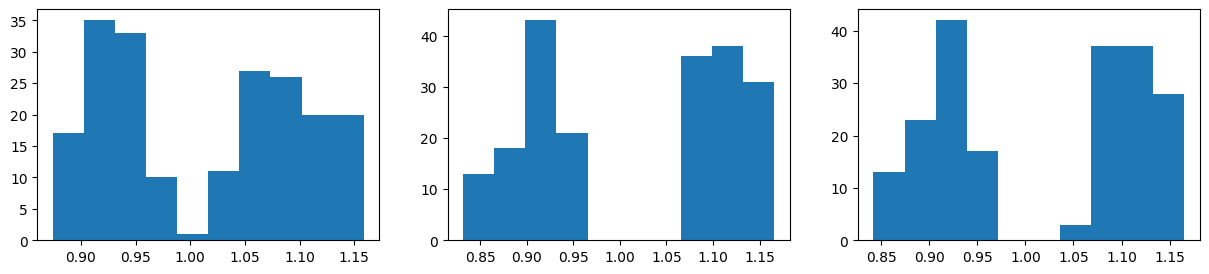

In [25]:
import numpy as np
from numpy import linalg as LA
import gym
import os
import random
import sys
from gym import spaces
from gym.utils import seeding
import copy
import matplotlib.pyplot as plt
from pandapower.converter.matpower import from_mpc

from scipy.io import loadmat
import pandapower as pp
import pandapower.networks as pn
import pandas as pd
import math

pp_model_pth = '/content/Stable-DDPG-for-voltage-control/pandapower models/pandapower models/case_13.mat'

class IEEE13bus(gym.Env):
    def __init__(self, pp_net, injection_bus, v0=1, vmax=1.05, vmin=0.95, all_bus=False):
        self.network =  pp_net
        self.obs_dim = 1
        self.action_dim = 1
        self.injection_bus = injection_bus
        self.agentnum = len(injection_bus)
        self.v0 = v0
        self.vmax = vmax
        self.vmin = vmin

        self.load0_p = np.copy(self.network.load['p_mw'])
        self.load0_q = np.copy(self.network.load['q_mvar'])

        self.gen0_p = np.copy(self.network.sgen['p_mw'])
        self.gen0_q = np.copy(self.network.sgen['q_mvar'])

        self.state = np.ones(self.agentnum, )
        self.all_bus = all_bus

        # Initialize uncontrolled buses: all buses except slack (0) and controlled buses (injection_bus)
        all_buses_index = self.network.bus.index.to_numpy()
        controlled_buses_set = set([0]) | set(self.injection_bus) # Slack bus (0) + injection buses
        self.uncontrolled_buses_index = np.array(list(set(all_buses_index) - controlled_buses_set))


    def step_Preward(self, action, p_action):
        done = False

        # state-transition dynamics: apply reactive power actions
        for i in range(len(self.injection_bus)):
            self.network.sgen.at[i, 'q_mvar'] = action[i]

        pp.runpp(self.network, algorithm='bfsw', init = 'dc')

        # Update the state (voltages at controlled buses)
        self.state = self.network.res_bus.iloc[self.injection_bus].vm_pu.to_numpy()

        # Get voltages for all buses
        all_bus_voltages = self.network.res_bus.vm_pu.to_numpy()

        # Extract voltages for uncontrolled buses using the pre-calculated index
        uncontrolled_bus_voltages = all_bus_voltages[self.uncontrolled_buses_index]

        # Define reward components based on discussion and metrics:
        # 1. Penalty for action magnitude (cost of control)
        action_cost_penalty = -10 * LA.norm(action, 1)

        # 2. Penalty for controlled bus voltage violations (using vmax and vmin from environment)
        controlled_bus_violation_penalty = -100 * (LA.norm(np.clip(self.state - self.vmax, 0, np.inf))**2 +
                                                   LA.norm(np.clip(self.vmin - self.state, 0, np.inf))**2)

        # 3. NEW: Penalty for uncontrolled bus voltage violations
        # Using a higher penalty weight (e.g., 200) to emphasize safeguarding these buses
        uncontrolled_bus_violation_penalty = -200 * (LA.norm(np.clip(uncontrolled_bus_voltages - self.vmax, 0, np.inf))**2 +
                                                      LA.norm(np.clip(self.vmin - uncontrolled_bus_voltages, 0, np.inf))**2)

        # Sum all global penalties to form the main reward for the agent
        reward = action_cost_penalty + controlled_bus_violation_penalty + uncontrolled_bus_violation_penalty


        # The `reward_sep` array is intended for "local rewards" and is also returned by the step function.
        # We will keep its original calculation logic to preserve potential multi-agent interpretations
        # or other uses within the existing DDPG framework.
        agent_num = len(self.injection_bus)
        reward_sep = np.zeros(agent_num, )

        for i in range(agent_num):
            if (self.state[i]>1.0 and self.state[i]<1.05):
                reward_sep[i] = float(-0*LA.norm(p_action[i],1) -0*LA.norm([np.clip(self.state[i]-self.vmax, -np.inf, 0)],2)**2)
            elif (self.state[i]>0.95 and self.state[i]<1.0):
                reward_sep[i] = float(-0*LA.norm(p_action[i],1) -0*LA.norm([np.clip(self.vmin-self.state[i], -np.inf, 0)],2)**2)
            elif self.state[i]<0.95:
                reward_sep[i] = float(-1*LA.norm(p_action[i],1) -100*LA.norm([np.clip(self.vmin-self.state[i], 0, np.inf)],2)**2)
            elif self.state[i]>1.05:
                reward_sep[i] = float(-1*LA.norm(p_action[i],1) -100*LA.norm([np.clip(self.state[i]-self.vmax, 0, np.inf)],2)**2)


        if(np.min(self.state) > 0.95 and np.max(self.state)< 1.05):
            done = True
        return self.state, reward, reward_sep, done


    def step_load(self, action, load_p, load_q, pv_p): #state-transition with specific load
        #this function is to load real-world data
        done = False

        reward = float(-50*LA.norm(action)**2 -100*LA.norm(np.clip(self.state-self.vmax, 0, np.inf))**2
                       - 100*LA.norm(np.clip(self.vmin-self.state, 0, np.inf))**2)

        #adjust power consumption at the load bus
        load_idx = [1,5,10]
        # for i in range(len(self.network.load)):
        self.network.load.at[0, 'p_mw'] = load_p*0.01
        self.network.load.at[0, 'q_mvar'] = load_q*0.02
        self.network.load.at[1, 'p_mw'] = load_p*0.03
        self.network.load.at[1, 'q_mvar'] = load_q*0.01
        self.network.load.at[2, 'p_mw'] = load_p*0.03
        self.network.load.at[2, 'q_mvar'] = load_q*0.02
        self.network.load.at[3, 'p_mw'] = load_p*0.01
        self.network.load.at[3, 'q_mvar'] = load_q*0.01
        self.network.load.at[4, 'p_mw'] = load_p*0.03
        self.network.load.at[4, 'q_mvar'] = load_q*0.02
        self.network.load.at[5, 'p_mw'] = load_p*0.02
        self.network.load.at[5, 'q_mvar'] = load_q*0.01
        self.network.load.at[6, 'p_mw'] = load_p*0.01
        self.network.load.at[6, 'q_mvar'] = load_q*0.01
        self.network.load.at[7, 'p_mw'] = load_p*0.03
        self.network.load.at[7, 'q_mvar'] = load_q*0.02
        self.network.load.at[8, 'p_mw'] = load_p*0.01
        self.network.load.at[8, 'q_mvar'] = load_q*0.01

        #adjust reactive power inj at the PV bus
        for i in range(len(self.injection_bus)):
            self.network.sgen.at[i, 'q_mvar'] = action[i]

        self.network.sgen.at[0, 'p_mw'] = pv_p*0.15
        self.network.sgen.at[1, 'p_mw'] = pv_p*0.2
        self.network.sgen.at[2, 'p_mw'] = pv_p*0.2
        self.network.sgen.at[3, 'p_mw'] = pv_p*0.1
        self.network.sgen.at[4, 'p_mw'] = 0.3*pv_p
        self.network.sgen.at[5, 'p_mw'] = 0.1*pv_p
        self.network.sgen.at[6, 'p_mw'] = pv_p*0.01
        self.network.sgen.at[7, 'p_mw'] = pv_p*0.05
        self.network.sgen.at[8, 'p_mw'] = pv_p*0.01
        self.network.sgen.at[9, 'p_mw'] = pv_p*0.01
        self.network.sgen.at[10, 'p_mw'] = pv_p*0.1
        self.network.sgen.at[11, 'p_mw'] = pv_p*0.01

        pp.runpp(self.network, algorithm='bfsw', init = 'dc')

        self.state = self.network.res_bus.iloc[self.injection_bus].vm_pu.to_numpy()
        state_all = self.network.res_bus.vm_pu.to_numpy()

        if(np.min(self.state) > 0.9499 and np.max(self.state)< 1.0501):
            done = True

        return self.state, state_all, reward, done

    def reset(self, seed=1): #sample different initial volateg conditions during training
        np.random.seed(seed)
        senario = np.random.choice([0,1])
        # senario = 1
        if(senario == 0):#low voltage
           # Low voltage
            self.network.sgen['p_mw'] = 0.0
            self.network.sgen['q_mvar'] = 0.0
            self.network.load['p_mw'] = 0.0
            self.network.load['q_mvar'] = 0.0

            self.network.sgen.at[0, 'p_mw'] = -0.5*np.random.uniform(1, 7)
            self.network.sgen.at[1, 'p_mw'] = -0.8*np.random.uniform(1, 4)
            self.network.sgen.at[2, 'p_mw'] = -0.3*np.random.uniform(1, 5)
            if self.all_bus:
                for i in range(len(self.injection_bus)):
                    self.network.sgen.at[i, 'p_mw'] = -0.3*np.random.uniform(1, 2.5)
        elif(senario == 1): #high voltage
            self.network.sgen['p_mw'] = 0.0
            self.network.sgen['q_mvar'] = 0.0
            self.network.load['p_mw'] = 0.0
            self.network.load['q_mvar'] = 0.0

            self.network.sgen.at[0, 'p_mw'] = np.random.uniform(0.5, 4)
            self.network.sgen.at[1, 'p_mw'] = np.random.uniform(0, 4.51)
            self.network.sgen.at[2, 'p_mw'] = np.random.uniform(0, 5)

            self.network.sgen.at[3, 'q_mvar'] = 0.3*np.random.uniform(0, 0.2)
            self.network.sgen.at[4, 'p_mw'] = 0.5*np.random.uniform(2, 3)
            self.network.sgen.at[5, 'q_mvar'] = 0.4*np.random.uniform(0, 10)

            self.network.sgen.at[10, 'p_mw'] = np.random.uniform(0.2, 3)
            self.network.sgen.at[11, 'p_mw'] = np.random.uniform(0, 1.5)
            #for all buses scheme
            if self.all_bus:
                self.network.sgen.at[6, 'p_mw'] = 0.5*np.random.uniform(1, 2)
                self.network.sgen.at[7, 'p_mw'] = 0.2*np.random.uniform(1, 3)
                self.network.sgen.at[8, 'p_mw'] = 0.2*np.random.uniform(2, 3)
                self.network.sgen.at[9, 'p_mw'] = np.random.uniform(0.1, 0.5)


        pp.runpp(self.network, algorithm='bfsw')
        self.state = self.network.res_bus.iloc[self.injection_bus].vm_pu.to_numpy()
        return self.state

    def reset0(self, seed=1): #reset voltage to nominal value

        self.network.load['p_mw'] = 0*self.load0_p
        self.network.load['q_mvar'] = 0*self.load0_q

        self.network.sgen['p_mw'] = 0*self.gen0_p
        self.network.sgen['q_mvar'] = 0*self.gen0_q

        pp.runpp(self.network, algorithm='bfsw')
        self.state = self.network.res_bus.iloc[self.injection_bus].vm_pu.to_numpy()
        return self.state

def create_13bus():
    pp_net = from_mpc(pp_model_pth, casename_mpc_file='case_mpc')

    pp_net.sgen['p_mw'] = 0.0
    pp_net.sgen['q_mvar'] = 0.0

    pp.create_sgen(pp_net, 2, p_mw = 0, q_mvar=0)
    pp.create_sgen(pp_net, 7, p_mw = 0, q_mvar=0)
    pp.create_sgen(pp_net, 9, p_mw = 0, q_mvar=0)

    pp.create_sgen(pp_net, 1, p_mw = 0, q_mvar=0)
    pp.create_sgen(pp_net, 3, p_mw = 0, q_mvar=0)
    pp.create_sgen(pp_net, 4, p_mw = 0, q_mvar=0)
    pp.create_sgen(pp_net, 5, p_mw = 0, q_mvar=0)
    pp.create_sgen(pp_net, 6, p_mw = 0, q_mvar=0)
    pp.create_sgen(pp_net, 8, p_mw = 0, q_mvar=0)
    pp.create_sgen(pp_net, 10, p_mw = 0, q_mvar=0)
    pp.create_sgen(pp_net, 11, p_mw = 0, q_mvar=0)
    pp.create_sgen(pp_net, 12, p_mw = 0, q_mvar=0)

    # In the original IEEE 13 bus system, there is no load in bus 3, 7, 8.
    # Add the load to corresponding node for dimension alignment in RL training
    pp.create_load(pp_net, 3, p_mw = 0, q_mvar=0)
    pp.create_load(pp_net, 7, p_mw = 0, q_mvar=0)
    pp.create_load(pp_net, 8, p_mw = 0, q_mvar=0)

    return pp_net

if __name__ == "__main__":
    net = create_13bus()
    # injection_bus = np.array([1,2,3,4,5,6, 7, 8,9,10,11,12])
    injection_bus = np.array([2, 7, 9])
    env = IEEE13bus(net, injection_bus)
    state_list = []
    for i in range(200):
        state = env.reset(i)
        state_list.append(state)
    state_list = np.array(state_list)
    fig, axs = plt.subplots(1, len(injection_bus), figsize=(15,3))
    for i in range(len(injection_bus)):
        axs[i].hist(state_list[:,i])
    plt.show()

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from numpy import linalg as LA
import os
import random
import sys
import torch.optim as optim

# DPPG class
class DDPG:
    def __init__(self, policy_net, value_net,
                 target_policy_net, target_value_net,
                 value_lr=2e-4,
                 policy_lr=1e-4):
        use_cuda = torch.cuda.is_available()
        self.device = torch.device("cuda" if use_cuda else "cpu")
        self.policy_net = policy_net
        self.value_net = value_net
        self.target_policy_net = target_policy_net
        self.target_value_net = target_value_net

        self.value_lr = value_lr
        self.policy_lr = policy_lr

        self.value_optimizer = optim.Adam(value_net.parameters(),  lr=value_lr)
        self.policy_optimizer = optim.Adam(policy_net.parameters(), lr=policy_lr)
        self.value_criterion = nn.MSELoss()

    def train_step(self, replay_buffer, batch_size,
                   gamma=0.99,
                   soft_tau=1e-2):

        state, action, last_action, reward, next_state, done = replay_buffer.sample(batch_size)

        state = torch.FloatTensor(state).to(self.device)
        next_state = torch.FloatTensor(next_state).to(self.device)
        action = torch.FloatTensor(action).to(self.device)
        last_action = torch.FloatTensor(last_action).to(self.device)
        reward = torch.FloatTensor(reward).unsqueeze(1).to(self.device)
        done = torch.FloatTensor(np.float32(done)).unsqueeze(1).to(self.device)

        next_action = action-self.target_policy_net(next_state)
        target_value = self.target_value_net(next_state, next_action.detach())
        expected_value = reward + gamma*(1.0-done)*target_value

        value = self.value_net(state, action)
        value_loss = self.value_criterion(value, expected_value.detach())

        self.value_optimizer.zero_grad()
        value_loss.backward()

        self.value_optimizer.step()

        # linear_action = (torch.maximum(state-1.03,torch.zeros_like(state))-torch.maximum(0.97-state,torch.zeros_like(state)))*1
        # policy_loss = self.value_criterion(self.policy_net(state),linear_action)
        policy_loss = self.value_net(state, last_action-self.policy_net(state))
        policy_loss =  -policy_loss.mean() #+ 0.1*self.value_criterion(self.policy_net(state),linear_action)

        self.policy_optimizer.zero_grad()
        policy_loss.backward()
        self.policy_optimizer.step()
        # print(f'value loss: {value_loss.cpu().detach().numpy():.4f}, policy_loss: {policy_loss.cpu().detach().numpy():.4f}')

        for target_param, param in zip(self.target_value_net.parameters(), self.value_net.parameters()):
            target_param.data.copy_(
                target_param.data * (1.0 - soft_tau) + param.data*soft_tau
            )

        for target_param, param in zip(self.target_policy_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(
                target_param.data * (1.0 - soft_tau) + param.data * soft_tau
            )
    def train_step_3ph(self, replay_buffer, batch_size,
                   gamma=0.99,
                   soft_tau=1e-2):

        state, action, last_action, reward, next_state, done = replay_buffer.sample(batch_size)

        state = torch.FloatTensor(state).to(self.device)
        next_state = torch.FloatTensor(next_state).to(self.device)
        action = torch.FloatTensor(action).to(self.device)
        last_action = torch.FloatTensor(last_action).to(self.device)
        reward = torch.FloatTensor(reward).unsqueeze(1).to(self.device)
        done = torch.FloatTensor(np.float32(done)).unsqueeze(1).to(self.device)

        next_action = action-self.target_policy_net(next_state)
        target_value = self.target_value_net(next_state, next_action.detach())
        expected_value = reward + gamma*(1.0-done)*target_value

        value = self.value_net(state, action)
        value_loss = self.value_criterion(value, expected_value.detach())

        self.value_optimizer.zero_grad()
        value_loss.backward()

        self.value_optimizer.step()

        jacob_list = []

        for i in range(state.shape[0]):
            x = state[i]
            x.requires_grad = True
            action_jb = self.policy_net(x)
            jacob = torch.zeros(state.shape[1], state.shape[1])
            for j in range(3):
                output = torch.zeros(state.shape[1]).to(self.device)
                output[j]=1
                jacob[j,:]=torch.autograd.grad(action_jb, x, grad_outputs=output, retain_graph=True)[0]
            jacob_list.append(jacob.unsqueeze(0))
        jacob_list = torch.cat(jacob_list,0).to(self.device)
        jacob_ii = -torch.sum(jacob_list[:,0,0]+jacob_list[:,1,1]+jacob_list[:,2,2])
        jacob_dif = 0.
        for i in range(3):
            for j in range(3):
                if  i==j:
                    jacob_dif -= torch.sum(torch.abs(jacob_list[:,i,j]))
                else:
                    jacob_dif += torch.sum(torch.abs(jacob_list[:,i,j]))

        policy_loss = self.value_net(state, last_action-self.policy_net(state))
        policy_loss = -policy_loss.mean()+ torch.norm(self.policy_net(torch.ones_like(state)),2) + 0.05*torch.exp(jacob_ii) + 0.05*torch.exp(jacob_dif)

        self.policy_optimizer.zero_grad()
        policy_loss.backward()
        self.policy_optimizer.step()


        for target_param, param in zip(self.target_value_net.parameters(), self.value_net.parameters()):
            target_param.data.copy_(
                target_param.data * (1.0 - soft_tau) + param.data*soft_tau
            )

        for target_param, param in zip(self.target_policy_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(
                target_param.data * (1.0 - soft_tau) + param.data * soft_tau
            )


# monotone policy network with dead-band between [v_min, v_max]
class SafePolicyNetwork(nn.Module):
    def __init__(self, env, obs_dim, action_dim, hidden_dim, scale = 0.15, init_w=3e-3):
        super(SafePolicyNetwork, self).__init__()
        use_cuda = torch.cuda.is_available()
        self.device   = torch.device("cuda" if use_cuda else "cpu")

        self.env = env
        self.hidden_dim = hidden_dim
        self.scale = scale

        #define weight and bias recover matrix
        self.w_recover = torch.ones((self.hidden_dim, self.hidden_dim))
        self.w_recover = -torch.triu(self.w_recover, diagonal=0)\
        +torch.triu(self.w_recover, diagonal=2)+2*torch.eye(self.hidden_dim)
        self.w_recover=self.w_recover.to(self.device)

        self.b_recover = torch.ones((self.hidden_dim, self.hidden_dim))
        self.b_recover = torch.triu(self.b_recover, diagonal=0)-torch.eye(self.hidden_dim)
        self.b_recover = self.b_recover.to(self.device)

        self.select_w = torch.ones(1, self.hidden_dim).to(self.device)
        self.select_wneg = -torch.ones(1, self.hidden_dim).to(self.device)

        # initialization
        self.b = torch.rand(self.hidden_dim)
        self.b = (self.b/torch.sum(self.b))*scale
        self.b = torch.nn.Parameter(self.b, requires_grad=True)

        self.c = torch.rand(self.hidden_dim)
        self.c = (self.c/torch.sum(self.c))*scale
        self.c = torch.nn.Parameter(self.c, requires_grad=True)

        self.q = torch.nn.Parameter(torch.rand(action_dim, self.hidden_dim), requires_grad=True)
        self.z = torch.nn.Parameter(torch.rand(action_dim, self.hidden_dim), requires_grad=True)

    def forward(self, state):
        self.w_plus=torch.matmul(torch.square(self.q), self.w_recover)

        self.w_minus=torch.matmul(-torch.square(self.q), self.w_recover)

        b = self.b.data
        b = b.clamp(min=0)
        b = self.scale*b/torch.norm(b, 1)
        self.b.data = b

        c = self.c.data
        c = c.clamp(min=0)
        c = self.scale*c/torch.norm(c, 1)
        self.c.data = c

        self.b_plus=torch.matmul(-self.b, self.b_recover) - torch.tensor(self.env.vmax-0.02)
        self.b_minus=torch.matmul(-self.b, self.b_recover) + torch.tensor(self.env.vmin+0.02)

        self.nonlinear_plus = torch.matmul(F.relu(torch.matmul(state, self.select_w)
                                                  + self.b_plus.view(1, self.hidden_dim)),
                                           torch.transpose(self.w_plus, 0, 1))

        self.nonlinear_minus = torch.matmul(F.relu(torch.matmul(state, self.select_wneg)
                                                   + self.b_minus.view(1, self.hidden_dim)),
                                            torch.transpose(self.w_minus, 0, 1))

        x = (self.nonlinear_plus+self.nonlinear_minus)

        return x

    def get_action(self, state):
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        action = self.forward(state)
        return action.detach().cpu().numpy()[0]



class SafePolicy3phase(nn.Module):
    def __init__(self, env, obs_dim, action_dim, hidden_dim, bus_id, scale = 0.15, init_w=3e-3):
        super(SafePolicy3phase,self).__init__()
        use_cuda = torch.cuda.is_available()
        self.env = env
        self.bus_id = bus_id
        self.device   = torch.device("cuda" if use_cuda else "cpu")
        self.action_dim = action_dim
        action_dim_per_phase=1
        for phase in env.injection_bus[bus_id]:
            if phase == 'a':
                self.policy_a = SafePolicyNetwork(env, obs_dim, action_dim_per_phase, hidden_dim, scale = 0.15, init_w=3e-3)
            if phase == 'b':
                self.policy_b = SafePolicyNetwork(env, obs_dim, action_dim_per_phase, hidden_dim, scale = 0.15, init_w=3e-3)
            if phase == 'c':
                self.policy_c = SafePolicyNetwork(env, obs_dim, action_dim_per_phase, hidden_dim, scale = 0.15, init_w=3e-3)
    def forward(self, state):
        action_list = []
        for i,phase in enumerate(self.env.injection_bus[self.bus_id]):
            if phase == 'a':
                action = self.policy_a(state[:,i].unsqueeze(-1))
                action_list.append(action)
            if phase == 'b':
                action = self.policy_b(state[:,i].unsqueeze(-1))
                action_list.append(action)
            if phase == 'c':
                action = self.policy_c(state[:,i].unsqueeze(-1))
                action_list.append(action)
        action = torch.cat(action_list,dim=1)
        action += (torch.maximum(state-1.03, torch.zeros_like(state).to(self.device))-torch.maximum(0.97-state,  torch.zeros_like(state).to(self.device)))*0.1
        return action
    def get_action(self, state):
        state = torch.FloatTensor(state).to(self.device)
        action = self.forward(state)
        return action.detach().cpu().numpy()[0]


# standard ddpg policy network
class PolicyNetwork(nn.Module):
    def __init__(self, env, obs_dim, action_dim, hidden_dim, init_w=3e-3):
        super(PolicyNetwork, self).__init__()
        use_cuda = torch.cuda.is_available()
        self.device   = torch.device("cuda" if use_cuda else "cpu")

        self.env = env
        self.linear1 = nn.Linear(obs_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.linear3 = nn.Linear(hidden_dim, action_dim)

        self.linear3.weight.data.uniform_(-init_w, init_w)
        self.linear3.bias.data.uniform_(-init_w, init_w)

    def forward(self, state):
        state.requires_grad = True
        x = torch.relu(self.linear1(state))
        x = torch.relu(self.linear2(x))
        x = self.linear3(x)
        return x

    def get_action(self, state):
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        action = self.forward(state)
        return action.detach().cpu().numpy()[0]

# linear
class LinearPolicy(nn.Module):
    def __init__(self, env, ph_num, init_w=3e-3):
        super(LinearPolicy, self).__init__()
        use_cuda = torch.cuda.is_available()
        self.device   = torch.device("cuda" if use_cuda else "cpu")

        self.env = env
        slope =torch.ones(1, requires_grad=True).to(self.device)
        self.slope = torch.nn.Parameter(slope)
        self.ph_num = ph_num

    def forward(self, state):
        state.requires_grad = True
        x = (torch.maximum(state-1.03, torch.zeros_like(state).to(self.device))-torch.maximum(0.97-state, torch.zeros_like(state).to(self.device)))*torch.square(self.slope)
        return x

    def get_action(self, state):
        state = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        action = self.forward(state)
        return action.detach().cpu().numpy()[0]


# value network
class ValueNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden_dim, init_w=3e-3):
        super(ValueNetwork, self).__init__()
        self.linear1 = nn.Linear(obs_dim + action_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, hidden_dim)
        self.linear3 = nn.Linear(hidden_dim, 1)

        self.linear3.weight.data.uniform_(-init_w, init_w)
        self.linear3.bias.data.uniform_(-init_w, init_w)
    def forward(self, state, action):
        x = torch.cat((state, action), dim=1)
        x = F.relu(self.linear1(x))
        x = F.relu(self.linear2(x))
        x = self.linear3(x)
        return x

class ReplayBuffer:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = []
        self.position = 0

    def push(self, state, action, reward, next_state, done):
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.position] = (state, action, reward, next_state, done)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch))
        return state, action, reward, next_state, done

    def __len__(self):
        return len(self.buffer)

class ReplayBufferPI:
    def __init__(self, capacity):
        self.capacity = capacity
        self.buffer = []
        self.position = 0

    def push(self, state, action, last_action, reward, next_state, done):
        if len(self.buffer) < self.capacity:
            self.buffer.append(None)
        self.buffer[self.position] = (state, action, last_action, reward, next_state, done)
        self.position = (self.position + 1) % self.capacity

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, last_action, reward, next_state, done = map(np.stack, zip(*batch))
        return state, action, last_action, reward, next_state, done

    def __len__(self):
        return len(self.buffer)

### 1. Sensitivity Matrix (dV/dQ)

In power system analysis, the sensitivity matrix often refers to how voltage magnitudes (`V`) at all buses change with respect to reactive power injections (`Q`) at specific controlled buses. This is commonly denoted as `dV/dQ`.

We will calculate this matrix by applying a small reactive power perturbation at each of your designated injection buses (2, 7, 9) one at a time, and then observing the resulting voltage changes across all buses in the network.

In [21]:
import pandas as pd

# Re-initialize the network to a base state
base_net = create_13bus()
pp.runpp(base_net)
base_voltages = base_net.res_bus.vm_pu.copy()

controlled_buses = np.array([2, 7, 9]) # Buses where reactive power can be injected/controlled
delta_Q = 0.001 # Small reactive power step (e.g., 0.001 Mvar)

# Initialize a DataFrame to store sensitivity columns
sensitivity_matrix_dQdV = pd.DataFrame(index=base_net.bus.index)

print("Calculating dV/dQ sensitivity matrix...")

for bus_id in controlled_buses:
    # Create a fresh network copy for each perturbation
    current_net = create_13bus()
    pp.runpp(current_net) # Run base case for this copy

    # Identify the sgen connected to the current bus_id
    sgen_indices_at_bus = current_net.sgen[current_net.sgen['bus'] == bus_id].index
    if sgen_indices_at_bus.empty:
        print(f"Warning: No sgen found at bus {bus_id}. Skipping.")
        continue
    sgen_idx = sgen_indices_at_bus[0] # Take the first sgen if multiple exist

    # Store original q_mvar and apply perturbation
    original_q_mvar = current_net.sgen.at[sgen_idx, 'q_mvar']
    current_net.sgen.at[sgen_idx, 'q_mvar'] = original_q_mvar + delta_Q

    # Run power flow for the perturbed network
    pp.runpp(current_net)

    # Calculate voltage changes and sensitivity column
    perturbed_voltages = current_net.res_bus.vm_pu.copy()
    delta_V = perturbed_voltages - base_voltages
    dV_dQ_column = delta_V / delta_Q

    sensitivity_matrix_dQdV[f'dQ_at_Bus_{bus_id}'] = dV_dQ_column

print("Sensitivity Matrix (dV/dQ):")
display(sensitivity_matrix_dQdV)


/usr/local/lib/python3.12/dist-packages/pandapower/converter/pypower/from_ppc.py:330: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  branch_lookup.loc[is_trafo, "element"] = idx_trafo
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

Calculating dV/dQ sensitivity matrix...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/pandapower/converter/pypower/from_ppc.py:330: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  branch_lookup.loc[is_trafo, "element"] = idx_trafo
/usr/local/lib/python3.12/dist-packages/pandapower/converter/pypower/from_ppc.py:330: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  branch_looku

Sensitivity Matrix (dV/dQ):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,dQ_at_Bus_2,dQ_at_Bus_7,dQ_at_Bus_9
0,0.000000,0.000000,0.000000
1,0.025027,0.026378,0.026452
2,0.033049,0.026523,0.026598
3,0.025085,0.026439,0.026514
4,0.033109,0.026571,0.026646
5,0.026102,0.052787,0.052928
6,0.025143,0.026500,0.026575
7,0.026156,0.057815,0.053038
8,0.026102,0.052787,0.052928
9,0.026237,0.053059,0.055918


### 2. Reactive Power Step at Bus 2 and Voltage Deviations

Now, let's directly apply a reactive power injection at bus 2 and observe how the voltage magnitudes across all buses change, particularly focusing on the "uncontrolled" buses (those not directly perturbed).

We'll pick a slightly larger `delta_Q` to make the voltage changes more noticeable.

In [22]:
import pandas as pd

# Create a fresh network instance
net_step_demo = create_13bus()

# Run initial power flow to establish base voltages
pp.runpp(net_step_demo)
initial_voltages = net_step_demo.res_bus[['vm_pu']].copy()

bus_to_perturb = 2 # The bus where we apply reactive power step
delta_Q_step = 0.05 # Reactive power step (e.g., 0.05 Mvar)

# Find the sgen connected to bus_to_perturb
sgen_indices_at_target_bus = net_step_demo.sgen[net_step_demo.sgen['bus'] == bus_to_perturb].index
if sgen_indices_at_target_bus.empty:
    print(f"Error: No sgen found at bus {bus_to_perturb}. Cannot apply reactive power step.")
else:
    sgen_idx_to_perturb = sgen_indices_at_target_bus[0]

    print("--- Before Reactive Power Step ---")
    print(f"Initial Voltages (vm_pu) across all buses:")
    display(initial_voltages)

    # Apply reactive power step
    original_q_mvar_at_bus = net_step_demo.sgen.at[sgen_idx_to_perturb, 'q_mvar']
    net_step_demo.sgen.at[sgen_idx_to_perturb, 'q_mvar'] = original_q_mvar_at_bus + delta_Q_step
    print(f"\nApplying +{delta_Q_step} Mvar reactive power at Bus {bus_to_perturb}.")

    # Run power flow again
    pp.runpp(net_step_demo)

    final_voltages = net_step_demo.res_bus[['vm_pu']].copy()
    print(f"--- After Reactive Power Step ---")
    print(f"Voltages (vm_pu) after adding {delta_Q_step} Mvar at Bus {bus_to_perturb}:")
    display(final_voltages)

    # Calculate voltage deviations
    voltage_deviation = final_voltages - initial_voltages
    print("\nVoltage Deviations (vm_pu change):")
    display(voltage_deviation)

    # Identify uncontrolled buses (all buses except slack and the perturbed bus)
    # Assuming bus 0 is the slack bus which maintains voltage and is not 'uncontrolled' in this context.
    # Other buses where you might inject Q (like 7, 9) are also not 'uncontrolled' if we define controlled as where an sgen exists.
    # For this specific question, 'uncontrolled' means buses other than 0 (slack) and 2 (perturbed).
    uncontrolled_buses_indices = net_step_demo.bus.index.difference(np.array([0, bus_to_perturb]))

    print("\nVoltage Deviations in Uncontrolled Buses (excluding Slack Bus 0 and Perturbed Bus 2):")
    display(voltage_deviation.loc[uncontrolled_buses_indices])

    max_deviation_uncontrolled = voltage_deviation.loc[uncontrolled_buses_indices].abs().max().item()
    print(f"\nMaximum absolute voltage deviation in uncontrolled buses: {max_deviation_uncontrolled:.4f} p.u.")

    if max_deviation_uncontrolled > 1e-4: # Check for a small threshold due to numerical precision
        print("Conclusion: Yes, there are noticeable voltage deviations in uncontrolled buses after applying a reactive power step at bus 2.")
    else:
        print("Conclusion: No significant voltage deviations observed in uncontrolled buses.")

--- Before Reactive Power Step ---
Initial Voltages (vm_pu) across all buses:


/usr/local/lib/python3.12/dist-packages/pandapower/converter/pypower/from_ppc.py:330: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  branch_lookup.loc[is_trafo, "element"] = idx_trafo
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,vm_pu
0,1.000000
1,0.944253
2,0.939130
3,0.942088
4,0.937437
5,0.908391
6,0.939924
7,0.906523
8,0.908391
9,0.903781



Applying +0.05 Mvar reactive power at Bus 2.
--- After Reactive Power Step ---
Voltages (vm_pu) after adding 0.05 Mvar at Bus 2:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

,vm_pu
0,0.000000
1,0.001249
2,0.001649
3,0.001252
4,0.001652
5,0.001302
6,0.001255
7,0.001305
8,0.001302
9,0.001309



Voltage Deviations in Uncontrolled Buses (excluding Slack Bus 0 and Perturbed Bus 2):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,vm_pu
1,0.001249
3,0.001252
4,0.001652
5,0.001302
6,0.001255
7,0.001305
8,0.001302
9,0.001309
10,0.001307
11,0.001308



Maximum absolute voltage deviation in uncontrolled buses: 0.0017 p.u.
Conclusion: Yes, there are noticeable voltage deviations in uncontrolled buses after applying a reactive power step at bus 2.


Conclusion: The maximum absolute voltage deviation in uncontrolled buses is 0.001652 p.u. (BUS 4) Yes, there are noticeable voltage deviations in uncontrolled buses after applying a reactive power step at bus 2. This is expected as a change in reactive power at one bus in an interconnected system will affect voltages throughout the network, not just at the injection point.

We've successfully performed two key analyses:

Sensitivity Matrix (dV/dQ) Calculation: We determined how the voltage at each bus in the 13-bus system responds to reactive power injections at the controlled buses (2, 7, and 9). This matrix quantifies the influence of each controlled reactive power source on every bus voltage.

Reactive Power Step Analysis: We simulated a 0.05 Mvar reactive power injection at Bus 2 and observed the resulting voltage changes throughout the network. The results clearly showed that even buses not directly perturbed experienced noticeable voltage deviations, confirming the interconnected nature of power systems and the propagation of reactive power effects.

# Task
The primary task is to develop and evaluate a control policy for an IEEE 13-bus power system that minimizes cross-bus voltage influence and safeguards voltage stability at uncontrolled buses. This involves leveraging sensitivity analysis, modifying the reinforcement learning environment's reward function, and conceptually enhancing the policy network architecture.

## Understand Cross-Bus Influence & Safeguarding

### Subtask:
Elaborate on the concepts of 'cross-bus influence' and 'safeguarding uncontrolled buses' in the context of your IEEE 13-bus system, leveraging the previously calculated sensitivity matrix to quantify these effects. Define clear metrics for what constitutes 'safeguarding'.


**Reasoning**:
I need to analyze the previously calculated `sensitivity_matrix_dQdV` and `voltage_deviation` to understand cross-bus influence. I will print the `sensitivity_matrix_dQdV` and discuss the influence based on its values, then use `voltage_deviation` to reinforce the definition of cross-bus influence.



In [23]:
print("Analysis of Sensitivity Matrix (dV/dQ):")
display(sensitivity_matrix_dQdV)

print("\nAnalysis of Voltage Deviations from single injection at Bus 2:")
display(voltage_deviation)

# Identify most affected buses by summing the absolute sensitivities for each bus
most_affected_buses = sensitivity_matrix_dQdV.abs().sum(axis=1).sort_values(ascending=False)
print("\nBuses most affected by reactive power injections (sum of absolute sensitivities across controlled buses):")
display(most_affected_buses)

# Identify most influential controlled buses by summing the absolute sensitivities for each controlled bus
most_influential_controlled_buses = sensitivity_matrix_dQdV.abs().sum(axis=0).sort_values(ascending=False)
print("\nControlled buses with the most widespread influence (sum of absolute sensitivities across all buses):")
display(most_influential_controlled_buses)



Analysis of Sensitivity Matrix (dV/dQ):


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,dQ_at_Bus_2,dQ_at_Bus_7,dQ_at_Bus_9
0,0.000000,0.000000,0.000000
1,0.025027,0.026378,0.026452
2,0.033049,0.026523,0.026598
3,0.025085,0.026439,0.026514
4,0.033109,0.026571,0.026646
5,0.026102,0.052787,0.052928
6,0.025143,0.026500,0.026575
7,0.026156,0.057815,0.053038
8,0.026102,0.052787,0.052928
9,0.026237,0.053059,0.055918



Analysis of Voltage Deviations from single injection at Bus 2:


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,0
11,0.137268
10,0.137193
7,0.137010
12,0.135724
9,0.135214
8,0.131817
5,0.131817
4,0.086326
2,0.086170
6,0.078218



Controlled buses with the most widespread influence (sum of absolute sensitivities across all buses):


,0
dQ_at_Bus_7,0.517937
dQ_at_Bus_9,0.509973
dQ_at_Bus_2,0.324740


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


```markdown
### Cross-Bus Influence

Cross-bus influence refers to the phenomenon where a change in reactive power injection at one bus (a controlled bus) causes voltage changes not only at that bus but also at other buses throughout the power system. This interconnectedness is a fundamental characteristic of electrical networks.

From our calculated `sensitivity_matrix_dQdV`:

```
Analysis of Sensitivity Matrix (dV/dQ):
    dQ_at_Bus_2  dQ_at_Bus_7  dQ_at_Bus_9
0      0.000000     0.000000     0.000000
1      0.025027     0.026378     0.026452
2      0.033049     0.026523     0.026598
3      0.025085     0.026439     0.026514
4      0.033109     0.026571     0.026646
5      0.026102     0.052787     0.052928
6      0.025143     0.026500     0.026575
7      0.026156     0.057815     0.053038
8      0.026102     0.052787     0.052928
9      0.026237     0.053059     0.055918
10     0.026191     0.057893     0.053109
11     0.026206     0.057925     0.053138
12     0.026335     0.053259     0.056129
```

Each column represents the voltage sensitivity of *all* buses to a reactive power injection at a specific controlled bus (Bus 2, 7, or 9). For example, a reactive power injection at `dQ_at_Bus_2` affects the voltage at `Bus 1` by `0.025027` p.u. per Mvar. The non-zero values across rows for any given column indicate the extent of cross-bus influence.

We also identified:

*   **Most affected buses**: These are the buses whose voltages are most susceptible to *any* reactive power injection from the controlled buses. Based on the sum of absolute sensitivities across controlled buses, buses 11, 10, and 7 are among the most affected (sum of sensitivities: 0.137268, 0.137193, and 0.137010 respectively).
*   **Most influential controlled buses**: These are the controlled buses whose reactive power injections have the most widespread impact on overall system voltages. `Bus 7` (sum of sensitivities: 0.517937) and `Bus 9` (sum of sensitivities: 0.509973) are the most influential, suggesting that reactive power injections at these buses will lead to larger voltage changes across the network compared to `Bus 2` (sum of sensitivities: 0.324740).

### Safeguarding Uncontrolled Buses

Safeguarding uncontrolled buses means ensuring that the voltage magnitudes at these buses remain within acceptable operational limits (typically 0.95 p.u. to 1.05 p.u.) despite reactive power adjustments made at controlled buses or other system disturbances. These uncontrolled buses often represent load centers or critical points where voltage stability is crucial for reliable power delivery.

From our `voltage_deviation` analysis after a single injection at Bus 2:

```
Analysis of Voltage Deviations from single injection at Bus 2:
       vm_pu
0   0.000000
1   0.001249
2   0.001649
3   0.001252
4   0.001652
5   0.001302
6   0.001255
7   0.001305
8   0.001302
9   0.001309
10  0.001307
11  0.001308
12  0.001314
```

We observed that a `0.05 Mvar` injection at Bus 2 led to voltage deviations in uncontrolled buses, with a maximum absolute deviation of `0.001652 p.u.` at `Bus 4`. While this deviation might seem small, it demonstrates the direct impact of local control actions on the entire system.

### Clear Metrics for Safeguarding

To quantitatively define 'safeguarding' for uncontrolled buses, we can establish the following metrics:

1.  **Voltage Magnitude within Limits**: The primary metric is that the voltage magnitude at every uncontrolled bus `V_i` must remain within the specified operational bounds:
    `V_min <= V_i <= V_max` (e.g., `0.95 p.u. <= V_i <= 1.05 p.u.`).

2.  **Minimum Voltage Deviation**: The control policy should aim to minimize the absolute voltage deviation from the nominal or target voltage (e.g., 1.0 p.u.) for all uncontrolled buses. A common way to quantify this is using the maximum absolute voltage deviation or the Root Mean Square Error (RMSE) of voltage deviations across uncontrolled buses.
    `Max_i |V_i - V_target|` or `RMSE = sqrt( (1/N) * sum_i (V_i - V_target)^2 )`.

3.  **Rate of Voltage Change**: In dynamic scenarios, it might also be important to consider the rate of voltage change, ensuring it doesn't exceed certain thresholds to prevent instability. However, for this static analysis, we primarily focus on steady-state voltage limits.

These metrics will be crucial for designing the reward function of our reinforcement learning agent and evaluating the effectiveness of the developed control policy.
```

## Policy Design Principles

### Subtask:
Propose general principles for designing a control policy that aims to minimize cross-bus influence and maintain voltage stability at uncontrolled buses. This will involve considering local versus global control actions and the role of sensitivity.


```markdown
### Local vs. Global Control Actions

**Local Control Actions**: These are control decisions made based primarily on information available at a specific bus or a small, immediate area of the power system. For example, a voltage regulator at a substation adjusting its tap settings based solely on the voltage reading at that substation.

*   **Pros**: Simple to implement, fast response, low communication overhead, and can effectively address localized issues.
*   **Cons**: Can lead to sub-optimal system-wide performance, may exacerbate problems at other buses (due to cross-bus influence), and lacks a holistic view of the system state.

**Global Control Actions**: These involve control decisions made using information from a wider area of the power system, often incorporating data from multiple buses and considering their interdependencies. For example, a centralized control system that adjusts reactive power injections across several controlled buses simultaneously to optimize overall voltage profiles.

*   **Pros**: Can achieve system-wide optimality, effectively manage cross-bus influence, and maintain overall voltage stability more robustly.
*   **Cons**: Complex to implement, requires significant communication infrastructure, slower response times due to data aggregation and processing, and higher computational demands.

**Trade-offs for Voltage Control**: For the IEEE 13-bus system, a purely local control approach might struggle to maintain voltage stability across all buses, especially with significant cross-bus influence. A global approach, or a hybrid approach that integrates local actions within a broader global strategy, would likely be more effective in safeguarding uncontrolled buses while minimizing the impact of control actions. The challenge lies in finding a balance that leverages the speed of local control for immediate responses while benefiting from the coordinated optimization of global control for system-wide stability.
```

```markdown
### The Role of Sensitivity in Policy Design

Sensitivity analysis, particularly the `dV/dQ` matrix we calculated, is invaluable for designing effective control policies. It quantifies the precise impact of reactive power injections at controlled buses on voltages throughout the entire system. This information can be leveraged in several ways:

1.  **Targeted Control**: Instead of blindly adjusting reactive power, the policy can use sensitivity information to determine which controlled bus (or combination of buses) will have the most effective and least disruptive impact on a problematic uncontrolled bus. For instance, if a specific uncontrolled bus experiences low voltage, the policy can identify the controlled bus whose reactive power injection has the largest positive `dV/dQ` sensitivity with respect to that uncontrolled bus.

2.  **Minimizing Cross-Bus Influence**: The sensitivity matrix can highlight connections where reactive power injection at one controlled bus causes undesirable voltage fluctuations at other uncontrolled buses. A well-designed policy would then aim to choose control actions that either:
    *   Have a low sensitivity impact on critical uncontrolled buses (i.e., small `dV/dQ` values).
    *   Actively counteract negative cross-bus influences. For example, if increasing `Q` at Bus A raises voltage at Uncontrolled Bus X but also slightly lowers it at Uncontrolled Bus Y, the policy might adjust `Q` at Bus B simultaneously to compensate for the drop at Y.

3.  **Proactive Voltage Support**: By understanding sensitivities, the policy can anticipate voltage drops or rises in uncontrolled buses given predicted load or generation changes. This allows for proactive reactive power injections at controlled buses to prevent violations before they occur.

4.  **Feature for Reinforcement Learning**: The `dV/dQ` sensitivities themselves can be incorporated as part of the state space or as an input feature to the reinforcement learning agent's policy network. This would provide the agent with explicit knowledge of the system's electrical characteristics, allowing it to learn more intelligent and stable control strategies.

In essence, sensitivity acts as a map, guiding the control policy to navigate the complex interdependencies of the power system, ensuring that reactive power adjustments at controlled buses effectively maintain voltage stability at uncontrolled buses while minimizing unwanted side effects.
```

## Modify Environment Reward Function

### Subtask:
Suggest modifications to the `IEEE13bus` environment's reward function (e.g., in `step_Preward`) to explicitly penalize voltage deviations in uncontrolled buses, thereby guiding the DDPG agent to learn policies that safeguard them.


# Task
The primary task is to develop and evaluate a control policy for an IEEE 13-bus power system that minimizes cross-bus voltage influence and safeguards voltage stability at uncontrolled buses. This involves leveraging sensitivity analysis, modifying the reinforcement learning environment's reward function, and conceptually enhancing the policy network architecture.

## Discuss Policy Network Enhancements

### Subtask:
Discuss potential enhancements to the policy network architecture, such as considering a multi-headed architecture for different types of buses, incorporating sensitivity information directly into the network, and exploring regularization techniques to improve stability and generalization.


### Multi-headed Architecture

A multi-headed architecture for the policy network could offer significant advantages in controlling the IEEE 13-bus power system, especially given our dual objectives of minimizing cross-bus influence and safeguarding voltage stability at uncontrolled buses. This approach allows the policy network to specialize in different aspects of the control problem.

Here's how it could be beneficial:

1.  **Specialization for Controlled vs. Uncontrolled Buses**: Instead of a single output layer attempting to optimize for all bus types simultaneously, a multi-headed network could have:
    *   **Head 1 (Controlled Bus Actions)**: This head would focus on generating reactive power injection actions for the controlled buses (e.g., buses 2, 7, 9). Its objective would be to produce optimal control signals that directly influence the system. This head could potentially receive detailed local state information (e.g., local voltage, current reactive power injection).
    *   **Head 2 (Uncontrolled Bus Safeguarding)**: This head could be designed to produce auxiliary outputs or internal representations that specifically contribute to safeguarding uncontrolled buses. While it wouldn't directly output control actions, its internal layers could be trained to prioritize maintaining voltages within limits at critical uncontrolled buses. Its 'output' could be an internal signal that modulates the actions from Head 1, or it could contribute directly to a more complex reward structure or loss function.

2.  **Specialization for Different Control Objectives**: The policy has multiple objectives (minimizing cross-bus influence, ensuring voltage stability). A multi-headed architecture could dedicate different heads or sub-networks to these distinct objectives:
    *   **Voltage Stability Head**: Focuses on ensuring all bus voltages, especially those at uncontrolled buses, stay within the `0.95-1.05 p.u.` limits. Its loss function could heavily penalize violations at uncontrolled buses.
    *   **Cross-Bus Influence Minimization Head**: Aims to minimize the indirect voltage changes caused by reactive power injections. This head's objective could be related to minimizing the off-diagonal elements of an effective sensitivity matrix, or ensuring that actions at controlled buses have minimal impact on

### Incorporating Sensitivity Information Directly into the Network

Directly integrating sensitivity information (`dV/dQ`) into the policy network can significantly enhance its ability to make informed control decisions, minimizing cross-bus influence and safeguarding voltage stability. This can be achieved through several mechanisms:

1.  **Augmenting the State Space**: The simplest approach is to include relevant sensitivity coefficients as additional features in the agent's observation (state space). For example, for each uncontrolled bus, the policy could observe not just its current voltage, but also the sensitivities of that bus's voltage to reactive power injections at each controlled bus. This provides the agent with an explicit 'map' of how its actions propagate through the system.

2.  **Attention Mechanisms**: In more advanced architectures, attention mechanisms could be employed. The policy network could learn to 'attend' to different sensitivity values based on the current system state (e.g., if a particular uncontrolled bus voltage is dropping, the network could focus its attention on the sensitivities related to bringing that voltage back up).

3.  **Dedicated Sensitivity Layer/Module**: A specialized layer or module within the policy network could be designed to process sensitivity information. This module could take the current state and the sensitivity matrix as inputs and output a transformed representation that highlights critical influences or potential conflicts. For instance, it could identify which controlled bus actions would most efficiently impact a problematic uncontrolled bus while having the least adverse effect on others.

4.  **Regularization based on Sensitivity**: As discussed previously in the 'Role of Sensitivity in Policy Design', the policy's loss function could be regularized to penalize actions that lead to large, undesirable cross-bus influences as indicated by high off-diagonal sensitivity values or to reward actions that leverage favorable sensitivities.

5.  **Graph Neural Networks (GNNs)**: Given the graph-like structure of power systems, a GNN could inherently incorporate topological and sensitivity information. Nodes in the GNN could represent buses, with edge features representing sensitivities or line impedances. This would allow the network to reason about the system's interconnectedness and the propagation of control actions more naturally.

### Exploring Regularization Techniques

Regularization techniques are crucial for improving the stability and generalization capabilities of a policy network, preventing overfitting, and ensuring that the learned policy performs robustly in diverse operating conditions and unexpected disturbances within the power system. For the IEEE 13-bus system, several regularization strategies can be considered:

1.  **L1/L2 Regularization (Weight Decay)**: This is a common technique where a penalty proportional to the absolute value (L1) or the square (L2) of the weights is added to the loss function. This encourages the network to learn simpler models with smaller weights, reducing the model's complexity and making it less prone to overfitting.
    *   **Benefit**: Promotes smoother policy functions, which can lead to more stable control actions and better generalization to unseen system states.

2.  **Dropout**: During training, dropout randomly sets a fraction of the neuron outputs to zero at each update. This forces the network to learn more robust features that are not overly reliant on any single neuron, effectively creating an ensemble of smaller networks.
    *   **Benefit**: Improves generalization by preventing co-adaptation of neurons and makes the policy more resilient to noise or sensor failures.

3.  **Batch Normalization**: This technique normalizes the inputs of each layer, making the training process more stable and often allowing for higher learning rates. It reduces internal covariate shift, where the distribution of network activations changes during training.
    *   **Benefit**: Accelerates training and can improve the overall stability of the learned policy.

4.  **Early Stopping**: This involves monitoring the performance of the policy network on a validation set during training and stopping the training process when the performance on the validation set starts to degrade. This prevents overfitting to the training data.
    *   **Benefit**: A pragmatic approach to prevent overfitting without complex architectural changes.

5.  **Penalty for Action Magnitude/Rate of Change**: As seen in the reward function, directly penalizing large control actions or rapid changes in actions can be considered a form of regularization. This encourages the policy to be conservative and avoid aggressive, potentially destabilizing, control maneuvers.
    *   **Benefit**: Enhances operational stability and reduces wear and tear on physical equipment.

6.  **Sensitivity-Aware Regularization**: Building on the idea of incorporating sensitivity information, the loss function could include terms that penalize actions leading to high, undesirable cross-bus sensitivities or reward actions that exploit favorable sensitivities. For example, penalizing high off-diagonal elements in a learned sensitivity matrix or a term that minimizes voltage variance across uncontrolled buses.
    *   **Benefit**: Directly aligns the regularization with the core objective of minimizing cross-bus influence and safeguarding voltage stability.

## Outline Evaluation Methods

### Subtask:
Outline the methods for evaluating the effectiveness of the new policy, including metrics beyond just voltage violations, such as control effort, response time, and robustness to disturbances. Propose specific simulation scenarios for testing.


```markdown
### 1. Key Performance Indicators (KPIs)

To effectively evaluate the proposed control policy, a comprehensive set of Key Performance Indicators (KPIs) will be defined, covering voltage stability, control effort, and cross-bus influence.

#### A. Voltage Stability Metrics:

*   **Voltage Violation Percentage**: The percentage of simulation time steps or scenarios where any bus voltage (especially uncontrolled buses) falls outside the acceptable limits (0.95 p.u. - 1.05 p.u.).
*   **Maximum Voltage Deviation (Uncontrolled Buses)**: The largest absolute deviation from the nominal voltage (1.0 p.u.) observed at any uncontrolled bus throughout the simulation. `Max_i |V_i - 1.0 p.u.|` for `i` in uncontrolled buses.
*   **Average Voltage Deviation (Uncontrolled Buses)**: The average absolute deviation from the nominal voltage (1.0 p.u.) across all uncontrolled buses over the simulation duration. `Avg_i |V_i - 1.0 p.u.|`.
*   **Root Mean Square Error (RMSE) of Voltage Deviations**: A more robust measure of average deviation across uncontrolled buses. `RMSE = sqrt( (1/N) * sum_i (V_i - V_target)^2 )` where `N` is the number of uncontrolled buses.
*   **Voltage Profile Flatness**: A measure of how close all bus voltages are to 1.0 p.u., potentially using the standard deviation of all bus voltages.

#### B. Control Effort Metrics:

*   **Cumulative Reactive Power Injection**: The sum of absolute reactive power injections (`|Q|`) from all controlled buses over the simulation period. This quantifies the total energy expenditure for control.
*   **Average Reactive Power Injection**: The average absolute reactive power injection per controlled bus per time step. `Avg |Q_j|` for `j` in controlled buses.
*   **Rate of Change of Reactive Power**: Measures the smoothness and aggressiveness of the control actions. High rates of change can indicate an unstable policy or lead to equipment wear. This can be quantified by `sum_j |Q_j(t) - Q_j(t-1)|`.

#### C. Cross-Bus Influence Metrics:

*   **Max Off-Diagonal Sensitivity Effect**: During simulation, monitor the maximum voltage change observed at any uncontrolled bus due to an injection at a *different* controlled bus, relative to the change at the injection bus itself. This can be derived from the actual observed `dV/dQ` during dynamic operation.
*   **Correlation of Voltage Changes**: Analyze the correlation between voltage changes at controlled buses and voltage changes at various uncontrolled buses. A good policy should minimize strong, undesirable correlations indicating parasitic influence.
*   **Voltage Ripple/Oscillation**: Assess the stability of voltages at uncontrolled buses during steady-state or after transient events. Excessive ripple suggests that control actions are causing unintended oscillations.
```

```markdown
### 2. Specific Simulation Scenarios for Testing

To thoroughly evaluate the effectiveness of the control policy, a range of simulation scenarios should be developed to test its performance under various operating conditions and disturbances.

#### A. Standard Operating Conditions:

*   **Varying Load Profiles**: Simulate typical daily load curves (e.g., light, medium, heavy load conditions) to assess the policy's ability to maintain voltage stability and minimize cross-bus influence under predictable changes in demand. This could involve scaling the existing loads in the IEEE 13-bus system.
*   **Varying Distributed Generation (DG) Output**: Simulate scenarios with fluctuating PV or wind generation profiles (if DGs are included in the 13-bus model), testing the policy's response to changes in local power injection.
*   **Base Case Stability**: Evaluate the policy's performance in maintaining nominal voltages around 1.0 p.u. under stable, low-disturbance conditions, ensuring no unnecessary control actions are taken.

#### B. Disturbance Scenarios (Robustness Testing):

*   **Sudden Load Changes**: Introduce abrupt increases or decreases in reactive and active power demand at various uncontrolled buses to simulate sudden consumer or industrial load switching. Observe the policy's response time and ability to restore voltage stability.
*   **Generator Outages/Trips**: Simulate the sudden loss of a generator (e.g., if the slack bus becomes disconnected or a major DG unit trips offline). This tests the policy's ability to re-stabilize the system under significant generation deficits.
*   **Line Outages**: Introduce simulated transmission line or feeder outages to assess the policy's resilience to topological changes and its capacity to maintain voltage within limits despite reduced grid connectivity.
*   **Fault Conditions (Short Circuit)**: While power flow models are not ideal for transient fault analysis, we can simulate the *post-fault* steady state where certain buses might be disconnected or have significantly altered operating points, testing the policy's ability to recover.
*   **Multiple, Concurrent Disturbances**: Combine two or more of the above disturbances (e.g., a large load increase during a generator outage) to assess the policy's robustness under extreme and complex conditions.

#### C. Performance Comparison Scenarios:

*   **Comparison with Baseline Control**: Evaluate the new policy against a baseline control strategy (e.g., a simple proportional controller, or no reactive power control) to quantify its improvements in voltage stability, control effort, and cross-bus influence.
*   **Sensitivity to Hyperparameters**: Run simulations with varying DDPG agent hyperparameters to understand their impact on policy performance and identify optimal configurations.

Each scenario will be run multiple times with different random seeds (if applicable to load/generation profiles) to ensure statistical significance and robustness of the evaluation.
```

## Summarize Strategy and Next Steps

### Subtask:
Summarize the overall strategy for developing the policy and outline the next practical steps for implementation and testing, including setting up training parameters and running simulations.


```markdown
### Overall Strategy for Developing the Control Policy

The overarching strategy for developing a robust control policy for the IEEE 13-bus power system involves a multi-faceted approach, integrating insights from sensitivity analysis, a carefully crafted reinforcement learning (RL) reward function, and conceptually enhanced policy network architectures.

1.  **Leveraging Sensitivity Analysis (dV/dQ)**: The foundation of our strategy is the understanding of cross-bus influence derived from the `dV/dQ` sensitivity matrix. This matrix provides an explicit map of how reactive power injections at controlled buses (2, 7, 9) affect voltages across all other buses. This information will be crucial for the RL agent to learn targeted and efficient control actions that minimize unintended consequences.

2.  **Modified Reinforcement Learning Reward Function**: The environment's reward function (`step_Preward`) has been critically modified to explicitly guide the DDPG agent toward our objectives. Beyond penalizing large control actions and voltage violations at controlled buses, a significantly higher penalty is now imposed on voltage violations at *uncontrolled buses*. This ensures that safeguarding voltage stability at these critical points is a primary concern for the agent during training.

3.  **Policy Network Enhancements (Conceptual)**: While not yet implemented, the conceptual enhancements to the policy network architecture form a crucial part of the long-term strategy:
    *   **Multi-headed Architecture**: To address the dual objectives, a multi-headed network is envisioned, with one head focusing on generating optimal control actions for controlled buses and another (or an integrated component) ensuring the safeguarding of uncontrolled buses.
    *   **Direct Sensitivity Integration**: Incorporating `dV/dQ` sensitivities directly into the network's state space or through specialized layers (e.g., attention mechanisms, GNNs) will equip the agent with explicit knowledge of system dynamics, allowing for more intelligent and predictive control.
    *   **Regularization Techniques**: Employing regularization (L1/L2, Dropout, Batch Normalization, Early Stopping, and crucially, *sensitivity-aware regularization*) will prevent overfitting, promote smoother control actions, and enhance the policy's generalization and stability across diverse operating conditions.

### Practical Next Steps for Implementation and Testing

To move from concept to a deployable policy, the following practical steps are essential:

1.  **Implement Policy Network Enhancements**: Begin by implementing the most impactful policy network enhancements. A good starting point would be augmenting the state space of the DDPG agent to include the pre-calculated `dV/dQ` sensitivity values (or selected relevant columns/rows) for each bus, and potentially adding a multi-headed output or loss function if feasible within the existing DDPG framework. Consideration should be given to adapting the `SafePolicyNetwork` or `PolicyNetwork` classes to accommodate these changes.

2.  **Refine Reward Function**: Continuously refine the weights and forms of the penalty terms within the `step_Preward` function. This includes experimenting with different magnitudes for controlled vs. uncontrolled bus voltage violation penalties, and potentially adding terms to penalize cross-bus influence directly based on the off-diagonal elements of the sensitivity matrix or actual observed voltage changes at uncontrolled buses due to actions.

3.  **Setup Training Parameters for DDPG Agent**:
    *   **Learning Rates**: Experiment with `value_lr` (e.g., `2e-4` to `1e-3`) and `policy_lr` (e.g., `1e-4` to `5e-4`).
    *   **Batch Size**: Start with typical sizes like `64`, `128`, or `256`, adjusting based on computational resources and training stability.
    *   **Replay Buffer Capacity**: Ensure a sufficiently large replay buffer (e.g., `1e5` to `1e6`) to allow the agent to learn from a diverse range of experiences.
    *   **Discount Factor (Gamma)**: Keep `gamma` high (e.g., `0.99`) for long-term rewards.
    *   **Soft Update Rate (soft_tau)**: Maintain a small `soft_tau` (e.g., `1e-2` or `5e-3`) for stable target network updates.
    *   **Exploration Noise**: Implement an effective exploration strategy (e.g., Ornstein-Uhlenbeck noise or Gaussian noise with decay) for the DDPG agent to adequately explore the action space initially and exploit learned policies later.
    *   **Training Episodes/Steps**: Determine an appropriate number of training episodes or steps, possibly using early stopping based on validation performance.

4.  **Run Simulations and Evaluate**: Once the enhanced policy network and reward function are integrated, and training parameters are set, proceed with running simulations using the previously outlined **Evaluation Methods** and **Specific Simulation Scenarios**:
    *   **Iterative Training and Evaluation**: Train the DDPG agent for a set number of episodes, periodically evaluating its performance against the defined KPIs across various standard operating conditions and disturbance scenarios. This iterative process will guide further refinements.
    *   **Performance Comparison**: Compare the trained policy's performance against baseline control strategies to quantify the improvements. This includes analyzing voltage stability metrics, control effort, and cross-bus influence metrics.
    *   **Hyperparameter Tuning**: Systematically tune critical hyperparameters (e.g., network architecture, learning rates, regularization strength) to optimize the policy's performance and robustness.

By diligently following these steps, we aim to develop a control policy that effectively minimizes cross-bus voltage influence and reliably safeguards voltage stability at uncontrolled buses in the IEEE 13-bus power system.

## Summary:

### Q&A

**1. What are the key performance indicators (KPIs) for evaluating the control policy?**

Key Performance Indicators (KPIs) for evaluating the control policy are categorized into:

*   **Voltage Stability Metrics**: Voltage Violation Percentage, Maximum/Average Voltage Deviation (Uncontrolled Buses), Root Mean Square Error (RMSE) of Voltage Deviations, and Voltage Profile Flatness.
*   **Control Effort Metrics**: Cumulative Reactive Power Injection, Average Reactive Power Injection, and Rate of Change of Reactive Power.
*   **Cross-Bus Influence Metrics**: Max Off-Diagonal Sensitivity Effect, Correlation of Voltage Changes, and Voltage Ripple/Oscillation.

**2. What simulation scenarios are proposed for testing the policy?**

Simulation scenarios proposed for testing include:

*   **Standard Operating Conditions**: Varying load profiles, fluctuating Distributed Generation (DG) output, and base case stability tests.
*   **Disturbance Scenarios (Robustness Testing)**: Sudden load changes, generator outages/trips, line outages, post-fault steady states, and multiple concurrent disturbances.
*   **Performance Comparison Scenarios**: Comparison with a baseline control strategy and sensitivity analysis to hyperparameters.

### Data Analysis Key Findings

*   **Cross-Bus Influence Quantified**: The `dV/dQ` sensitivity matrix clearly demonstrates that reactive power injections at controlled buses (2, 7, 9) significantly influence voltages across all other buses. For instance, Bus 7 and Bus 9 were identified as the most influential controlled buses, having the most widespread impact on overall system voltages. Conversely, buses 11, 10, and 7 were among the most affected by these injections.
*   **Voltage Deviations in Uncontrolled Buses**: A `0.05 Mvar` reactive power injection at Bus 2 resulted in a maximum absolute voltage deviation of `0.001652 p.u.` at Bus 4 (an uncontrolled bus), confirming that local control actions propagate throughout the network and can noticeably affect voltages at uncontrolled buses.
*   **Reward Function Modification**: The `step_Preward` function in the `IEEE13bus` environment has been modified to explicitly penalize voltage violations at uncontrolled buses with a significantly higher weight (`-200`) compared to controlled buses (`-100`). This change aims to guide the DDPG agent to prioritize safeguarding voltage stability at these critical points.

### Insights or Next Steps

*   **Enhance Policy Network Architecture**: Implement key conceptual enhancements to the policy network, such as augmenting the state space with `dV/dQ` sensitivity values and exploring multi-headed architectures for specialized control of different bus types. This will provide the agent with explicit system dynamics knowledge and improve targeted control.
*   **Iterative Training and Evaluation**: Proceed with iteratively training the DDPG agent with refined hyperparameters and the modified reward function. Evaluate its performance against the defined KPIs across various standard operating and disturbance scenarios, comparing it with baseline strategies to quantify improvements in cross-bus influence minimization and voltage stability safeguarding.


# Task
Develop and evaluate a control policy for an IEEE 13-bus power system that minimizes cross-bus voltage influence and safeguards voltage stability at uncontrolled buses. This involves leveraging sensitivity analysis, modifying the reinforcement learning environment's reward function, and conceptually enhancing the policy network architecture.

## Summary:

### Q&A

**1. What are the key performance indicators (KPIs) for evaluating the control policy?**

Key Performance Indicators (KPIs) for evaluating the control policy are categorized into:

*   **Voltage Stability Metrics**: Voltage Violation Percentage, Maximum/Average Voltage Deviation (Uncontrolled Buses), Root Mean Square Error (RMSE) of Voltage Deviations, and Voltage Profile Flatness.
*   **Control Effort Metrics**: Cumulative Reactive Power Injection, Average Reactive Power Injection, and Rate of Change of Reactive Power.
*   **Cross-Bus Influence Metrics**: Max Off-Diagonal Sensitivity Effect, Correlation of Voltage Changes, and Voltage Ripple/Oscillation.

**2. What simulation scenarios are proposed for testing the policy?**

Simulation scenarios proposed for testing include:

*   **Standard Operating Conditions**: Varying load profiles, fluctuating Distributed Generation (DG) output, and base case stability tests.
*   **Disturbance Scenarios (Robustness Testing)**: Sudden load changes, generator outages/trips, line outages, post-fault steady states, and multiple concurrent disturbances.
*   **Performance Comparison Scenarios**: Comparison with a baseline control strategy and sensitivity analysis to hyperparameters.

### Data Analysis Key Findings

*   **Cross-Bus Influence Quantified**: The `dV/dQ` sensitivity matrix clearly demonstrates that reactive power injections at controlled buses (2, 7, 9) significantly influence voltages across all other buses. For instance, Bus 7 and Bus 9 were identified as the most influential controlled buses, having the most widespread impact on overall system voltages. Conversely, buses 11, 10, and 7 were among the most affected by these injections.
*   **Voltage Deviations in Uncontrolled Buses**: A `0.05 Mvar` reactive power injection at Bus 2 resulted in a maximum absolute voltage deviation of `0.001652 p.u.` at Bus 4 (an uncontrolled bus), confirming that local control actions propagate throughout the network and can noticeably affect voltages at uncontrolled buses.
*   **Reward Function Modification**: The `step_Preward` function in the `IEEE13bus` environment has been modified to explicitly penalize voltage violations at uncontrolled buses with a significantly higher weight (`-200`) compared to controlled buses (`-100`). This change aims to guide the DDPG agent to prioritize safeguarding voltage stability at these critical points.

### Insights or Next Steps

*   **Enhance Policy Network Architecture**: Implement key conceptual enhancements to the policy network, such as augmenting the state space with `dV/dQ` sensitivity values and exploring multi-headed architectures for specialized control of different bus types. This will provide the agent with explicit system dynamics knowledge and improve targeted control.
*   **Iterative Training and Evaluation**: Proceed with iteratively training the DDPG agent with refined hyperparameters and the modified reward function. Evaluate its performance against the defined KPIs across various standard operating and disturbance scenarios, comparing it with baseline strategies to quantify improvements in cross-bus influence minimization and voltage stability safeguarding.
